# Model Development
---

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import rioxarray as rxr

In [17]:
"""Read in data."""

fp_canopy = "/mnt/c/Users/sebas/Documents/projects/multimodal-canopy/data/canopy_metrics/bc_093j012_4_20240715_20240715.tif"
fp_s1 = "/mnt/c/Users/sebas/Documents/projects/multimodal-canopy/data/sar/s1.tif"
fp_s2 = "/mnt/c/Users/sebas/Documents/projects/multimodal-canopy/data/spectral/s2.tif"
fp_alos = "/mnt/c/Users/sebas/Documents/projects/multimodal-canopy/data/sar/alos.tif"

canopy = rxr.open_rasterio(fp_canopy, masked=True)
s1 = rxr.open_rasterio(fp_s1, masked=True)
s2 = rxr.open_rasterio(fp_s2, masked=True)
alos = rxr.open_rasterio(fp_alos, masked=True)

In [20]:
"""Spacially align data."""

s1_reproj = s1.rio.reproject_match(canopy)
s2_reproj = s2.rio.reproject_match(canopy)
alos_reproj = alos.rio.reproject_match(canopy)

In [21]:
alos_reproj.rio.to_raster("alost_aligned.tif")

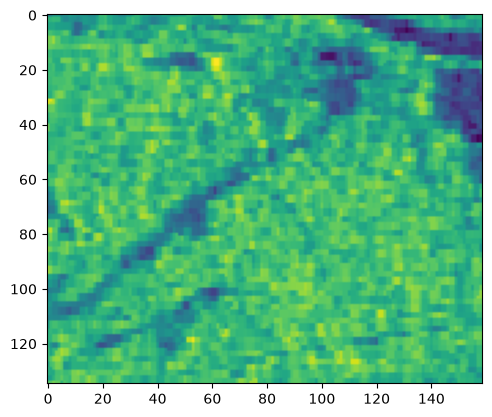

In [29]:
plt.imshow(alos_reproj[0])

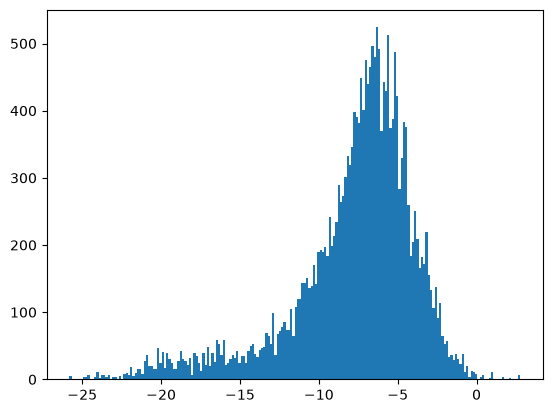

In [30]:
plt.hist(np.array(alos_reproj[0]).flatten(), bins=200)
plt.show()